<a href="https://colab.research.google.com/github/keshav123333/langgraph/blob/main/lecture6/lecture6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install langchain-huggingFace langgraph


In [41]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="text-generation",


    temperature=0.7
)
model=ChatHuggingFace(llm=llm)

In [18]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [25]:
class BMIState(TypedDict):
  weight_kg: float
  height_m:float
  bmi: float
  category:str


In [26]:
def calculate_bmi(state: BMIState)->BMIState:
  state['bmi']=state['weight_kg']/(state['height_m']**2)
  return state

def label_bmi(state:BMIState)->BMIState:
  bmi=state["bmi"]
  if bmi>24:
    state["category"]="overweight"
  elif bmi<18:
    state["category"]="underweight"
  else:
    state["category"]="normal"
  return state

In [27]:
#define the grapj
graph=StateGraph(BMIState)
#create node ofr graph
graph.add_node('calculate_bmi',calculate_bmi) #ye humne ek nodde ade adddefine kiya ab node aise hoga
graph.add_node('label_bmi',label_bmi)
#add edges to your graph

# start-> calculate_bmi-> end aise ek node

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('calculate_bmi',END)

#compile

workflow=graph.compile()


In [28]:
#excute the workflow

initial_state={"height_m":2,"weight_kg":100}
output_state=workflow.invoke(initial_state) # ye out bhi ek state hi deta dict ki
print(output_state)

{'weight_kg': 100, 'height_m': 2, 'bmi': 25.0, 'category': 'overweight'}


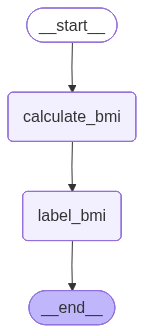

In [29]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

# LLM from langraph

In [30]:
class QuesAns(TypedDict):
  question:str
  answer:str

In [31]:
def llmmodule(state:QuesAns)->QuesAns:
  ques=state["question"]
  prompt=f"Answer this question {ques}"
  ans=model.invoke(prompt).content
  state["answer"]=ans
  return state


In [32]:
graph1=StateGraph(QuesAns)

# node ko specffy
graph1.add_node("llm",llmmodule)

#define track

graph1.add_edge(START,"llm")
graph1.add_edge("llm",END)

#compile

workflow1=graph1.compile()

In [33]:
initial_state={"question":"what is the capital of india"}
output_state=workflow1.invoke(initial_state)
print(output_state)

{'question': 'what is the capital of india', 'answer': 'The capital of India is New Delhi.'}


# Blog
prac ke liye hai yaar ye like tu dekh ke kar sakta haiisme ek baat


## flow
topic se ek outline gen then uss outline ke hisab se blog gen


isse prompt chaining as do node mein llm use


In [34]:
class Blog(TypedDict):
  title:str
  outline:str
  blog:str

In [35]:
# outline create

def outline(state:Blog)->Blog:
  #title fetch
  title=state["title"]
  #prompt gen
  prompt=f"write an outline for this topic={title}"

  #llm feed

  outline=model.invoke(prompt).content

  state["outline"]=outline
  return state





In [36]:
# outline ke hisab se blog

def bloggen(state:Blog)->Blog:
  #title fetch
  title=state["title"]
  outline=state["outline"]

  #prompt

  prompt=f"write a blog on this topic={title} using this outline /n outline={outline}"

  #model

  blog=model.invoke(prompt).content

  state["blog"]=blog

  return state



In [37]:
graph2=StateGraph(Blog)

#define node
graph2.add_node("outline",outline)
graph2.add_node("blog",bloggen)

#connect node

graph2.add_edge(START,"outline")
graph2.add_edge("outline","blog")
graph2.add_edge("blog",END)


workflow2=graph2.compile()

In [38]:
input_schema={"title":"Curroption in india"}

output=workflow2.invoke(input_schema)
print(output)

{'title': 'Curroption in india', 'outline': '**Corruption in India: An Outline**\n\nI. **Introduction**\n   - Definition of corruption\n   - Significance of corruption in India\n   - Brief overview of the problem\n\nII. **History of Corruption in India**\n   - Post-Independence era: Early signs of corruption\n   - 1960s-1980s: Corruption during the Emergency and its aftermath\n   - 1990s-present: Growing concerns and increasing corruption\n\nIII. **Types of Corruption in India', 'blog': "**Corruption in India: A Persistent Blot on the Nation's Democracy**\n\n**Introduction**\n\nCorruption is the cancer that has been eating away at the vitals of India's democratic system. It is a pervasive phenomenon that has become an integral part of the country's culture, affecting every aspect of life, from politics and bureaucracy to business and society. In this article, we will delve into the history of corruption in India, its various forms, and the reasons behind its persistence.\n\n**Definitio

In [39]:
output["outline"]

'**Corruption in India: An Outline**\n\nI. **Introduction**\n   - Definition of corruption\n   - Significance of corruption in India\n   - Brief overview of the problem\n\nII. **History of Corruption in India**\n   - Post-Independence era: Early signs of corruption\n   - 1960s-1980s: Corruption during the Emergency and its aftermath\n   - 1990s-present: Growing concerns and increasing corruption\n\nIII. **Types of Corruption in India'

In [40]:
output["blog"]

"**Corruption in India: A Persistent Blot on the Nation's Democracy**\n\n**Introduction**\n\nCorruption is the cancer that has been eating away at the vitals of India's democratic system. It is a pervasive phenomenon that has become an integral part of the country's culture, affecting every aspect of life, from politics and bureaucracy to business and society. In this article, we will delve into the history of corruption in India, its various forms, and the reasons behind its persistence.\n\n**Definition of"

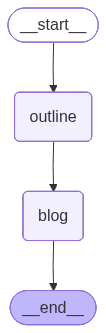

In [42]:
Image(workflow2.get_graph().draw_mermaid_png())